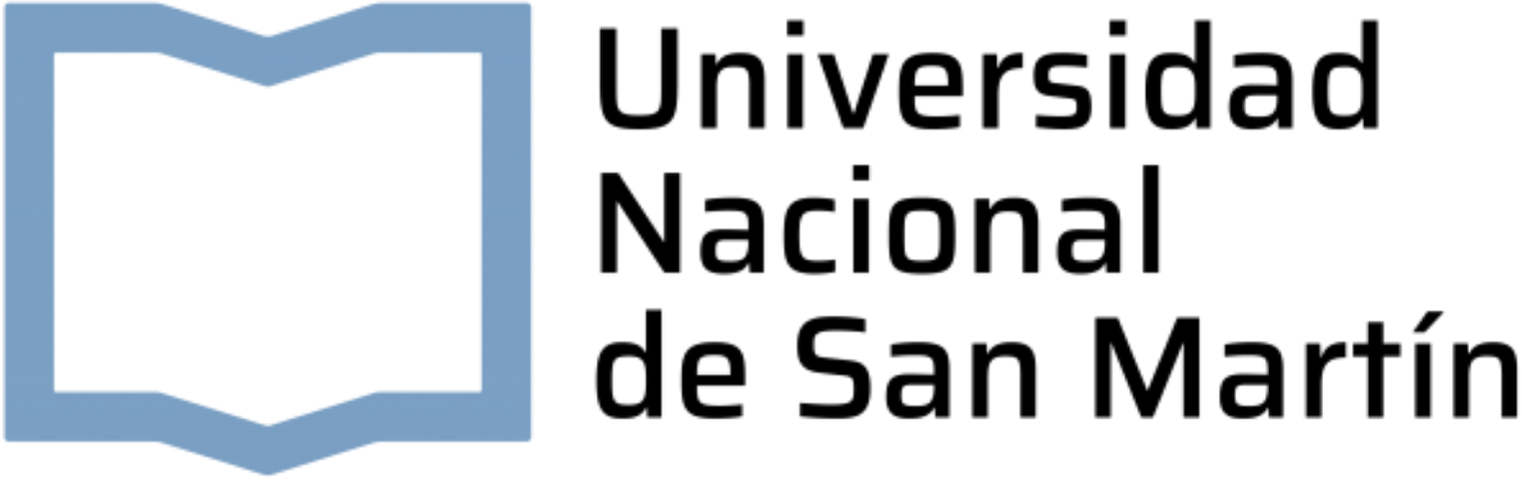

# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.
# Cristóbal Contador

## Introducción

En esta práctica se tiene como objetivo armar y simular el efecto de desparramo espectral (spectral leakage) que ocurre al calcular la Transformada Discreta de Fourier (DFT) sobre una señal senoidal. La idea es ver la relación entre el truncamiento de una señal pura y la naturaleza discreta del muestreo en el dominio frecuencial.En este trabajo nos enfocamos en analizar cómo se modifica el comportamiento del espectro de una senoidal al variar su frecuencia respecto a la resolución espectral ($\Delta f$), mediante el parámetro $k_0$:
* Bin exacto ($k_0 = N/4$): caso donde la frecuencia coincide perfectamente con una muestra de la DFT (sintonía ideal).
* Desintonía intermedia ($k_0 = N/4 + 0.25$): caso donde la frecuencia descalza moderadamente respecto a la grilla de la DFT.
* Desintonía máxima ($k_0 = N/4 + 0.5$): caso donde la frecuencia descalza pero cae en el punto medio entre dos bins, alcanzando la máxima pérdida de amplitud (scalloping loss) y desparramo espectral.

A lo largo de esta simulación se analizarán estos efectos mediante tres instancias principales:
* Densidad Espectral de Potencia (PSD) de cada senoidal, para observar visualmente cómo la desintonía cambia la distribucion de la energía en el espectro.
* Verificación de potencia mediante la Identidad de Parseval, para comprobar la conservación de energía y ver como senoidales con diferencias de pocos Hertz de diferencia muestran espectros tan diferentes.
* Interpolación espectral mediante Zero Padding ($9N$ ceros), para analizar cómo el incremento en la densidad de muestreo frecuencial cambia nuestros graficos.


## **a)** Sea $k_0 = N/4$, $k_0 = N/4 + 0.25$ y $k_0 = N/4 + 0.5$. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a $\Delta f$. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

Definimos nuestra función y sus parametros.

In [49]:
import numpy as np
import matplotlib.pyplot as plt


def mi_funcion_sen(a, ff, nn, fs):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    xx = a * np.sin(2 * np.pi * ff * tt)

    return tt, xx


a = np.sqrt(2)
fs = 1000
Ts = 1 / fs
N = 1000

# Tres valores de k0
k = [
    N / 4,
    N / 4 + 0.25,
    N / 4 + 0.5
]

frec = np.arange(0, fs / 2, fs / N)


Generamos la señal y su primer espectro con k=N/4 que tienen que estar en f0 = 250Hz y caeria en el bin 250.

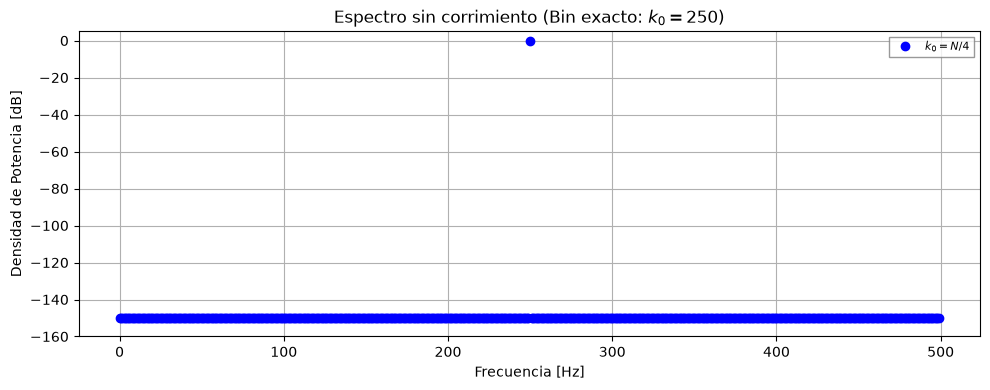

In [50]:
f0_1 = k[0] * (fs / N)

tt, xx1 = mi_funcion_sen(a, f0_1, N, fs)

fxx1 = np.fft.fft(xx1) / N
fmxx1 = fxx1[:N // 2]
pxx1 = 2 * (np.abs(fmxx1)) ** 2

pdbxx1 = 10 * np.log10(pxx1 + 1e-15)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    frec,
    pdbxx1,
    color='blue',
    linewidth=1.8,
    linestyle='none',
    marker='o',
    label=r'$k_0 = N/4$'
)

ax.set_title("Espectro sin corrimiento (Bin exacto: $k_0 = 250$)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_ylim(-160, 5)
ax.grid(True)
ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor='gray',
    fontsize=8
)

plt.tight_layout()
plt.show()

> **Figura 1.** Espectro de la señal sinoidial sin corrimiento. 

En la **Figura 1** podemos observar cómo se cumple rigurosamente lo esperado teóricamente: la componente espectral cae exactamente en $f_0 = 250\text{ Hz}$  (bin $k=250$). La parte del grafico que corresponde a la frecuencia compleja conjugada en donde cae en  $750\text{ Hz}$ ($f_S - f_0$) no se incluye al graficar el espectro unilateral hasta la frecuencia de Nyquist ($f_S/2 = 500\text{ Hz}$) donde nuestra señal pasa a espejarse.
Toda la energía de la senoidal se concentra de forma limpia en este único bin, alcanzando el pico máximo de $0\text{ dB}$ (correspondiente a la potencia unitaria de $1\text{ W}$). Como los demás bins caen exactamente sobre los ceros de cruce de la función sinc, el resto del espectro permanece en el piso, confirmando la ausencia total de desparramo espectral (zero leakage).

Ahora generamos la señal y su segundo espectro con k=N/4 + 0.25 que tienen que estar en f0 = 250.25 Hz y no lograria caer justo en el bin 250, por lo que esperamos ver desparramo espectral.

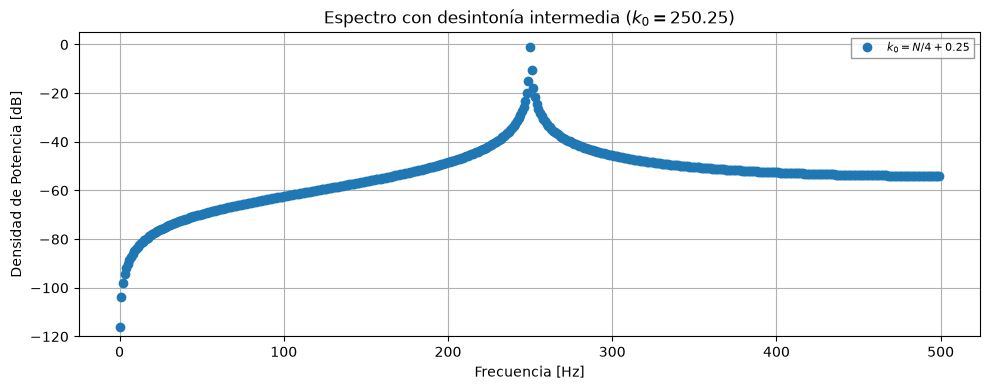

In [51]:
#%%
f0_2 = k[1] * (fs / N)

tt, xx2 = mi_funcion_sen(a, f0_2, N, fs)

fxx2 = np.fft.fft(xx2) / N
fmxx2 = fxx2[:N // 2]
pxx2 = 2 * (np.abs(fmxx2)) ** 2

pdbxx2 = 10 * np.log10(pxx2 + 1e-15)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    frec,
    pdbxx2,
    linewidth=1.8,
    linestyle='none',
    marker='o',
    label=r'$k_0 = N/4 + 0.25$'
)

ax.set_title("Espectro con desintonía intermedia ($k_0 = 250.25$)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_ylim(-120, 5)
ax.grid(True)
ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor='gray',
    fontsize=8
)

plt.tight_layout()
plt.show()


> **Figura 2.** Espectro de la señal sinoidial con un corrimiento de +0.25Hz. 

En la **Figura 2** podemos observar el fenómeno de desparramo espectral (spectral leakage).
Al estar la frecuencia en $f_0 = 250.25\text{ Hz}$, la energía de la señal no logra concentrarse en un único bin y se distribuye a lo largo del espectro. Como $250.25$ se encuentra más cerca del bin $250$ que del bin $251$, el bin $250$ es el que captura la mayor parte de energía.
Asimismo, se puede observa que el pico muestreado no alcanza los $0\text{ dB}$; esto no se debe a una pérdida de potencia real de la señal (la cual se conserva por Parseval), sino a la pérdida por no calzar (scalloping loss): el verdadero máximo de la sinc está en $250.25\text{ Hz}$ y la DFT la evalúa fuera de su centro.

Ahora generamos la señal y su tercer espectro con k=N/4 + 0.5 que tienen que estar en f0 = 250.5 Hz y no lograra caer justo en el bin 250, ni en el de 251, por lo que esperamos ver desparramo espectral, pero más que en el grafico anterior, debido a que ahora esta justo en el centro de ambos bines, el de 250 y el de 251.

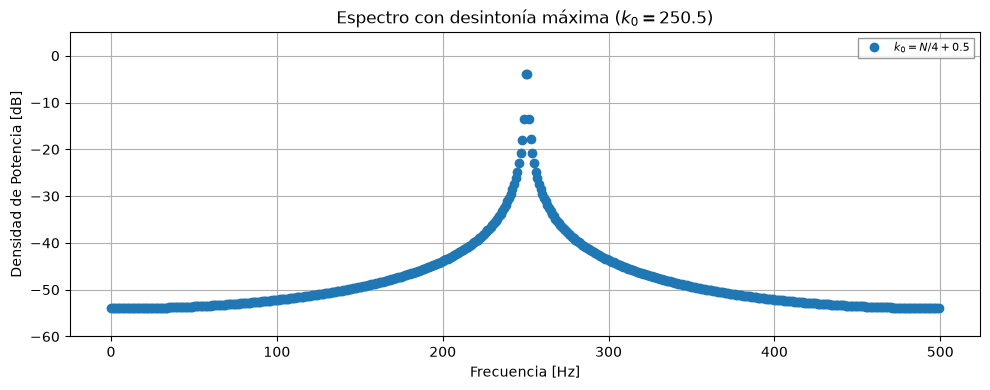

In [52]:
f0_3 = k[2] * (fs / N)

tt, xx3 = mi_funcion_sen(a, f0_3, N, fs)

fxx3 = np.fft.fft(xx3) / N
fmxx3 = fxx3[:N // 2]
pxx3 = 2 * (np.abs(fmxx3)) ** 2

pdbxx3 = 10 * np.log10(pxx3 + 1e-15)

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    frec,
    pdbxx3,
    linewidth=1.8,
    linestyle='none',
    marker='o',
    label=r'$k_0 = N/4 + 0.5$'
)

ax.set_title("Espectro con desintonía máxima ($k_0 = 250.5$)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_ylim(-60, 5)
ax.grid(True)
ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor='gray',
    fontsize=8
)

plt.tight_layout()
plt.show()


> **Figura 3.** Espectro de la señal sinoidial con un corrimiento de +0.5Hz. 

En la **Figura 3** podemos observar el caso de máximo desparramo espectral (spectral leakage). Como la frecuencia de la señal ($f_0 = 250.5\text{ Hz}$) cae justo en medio de dos bines, los bins $250$ y $251$, la energía se reparte simétricamente entre ambos lados, provocando que el desparramo este en su nivel más alto de todo el espectro. Asimismo, este caso presenta la máxima pérdida por no calzar (scalloping loss), debido a que la DFT evalúa la función sinc justo en la mitad de camino entre su pico central y su primer cruce por cero, la amplitud medida en los bins $250$ y $251$ sufre una caída importante respecto al nivel ideal de $0\text{ dB}$).

## **b)** Verificar la potencia unitaria de cada PSD, puede usar la identidad de Parseval. En base a la teoría estudiada. Discuta la razón por la cual una señal senoidal tiene un espectro tan diferente respecto a otra de muy pocos Hertz de diferencia. 

Primero haremos el codigo de los calculos de las potencias:

In [53]:
p_t1, p_f1 = np.mean(xx1**2), np.sum(pxx1) 
p_t2, p_f2 = np.mean(xx2**2), np.sum(pxx2)
p_t3, p_f3 = np.mean(xx3**2), np.sum(pxx3)

Ahora armamos una tabla comparativa con ayuda de las librerias de python:

In [54]:
import pandas as pd 
from IPython.display import display

tabla_data = {
    'Caso (k0)': [
        '250',
        '250 + 0,25',
        '250 + 0.5'
    ],
    'Potencia Tiempo [W]': [
        p_t1,
        p_t2,
        p_t3
    ],
    'Potencia Frecuencia [W]': [
        p_f1,
        p_f2,
        p_f3
    ]
}

df_parseval = pd.DataFrame(tabla_data)

display(df_parseval)

,Caso (k0),Potencia Tiempo [W],Potencia Frecuencia [W]
0,250,1.000,1.000000
1,"250 + 0,25",0.999,0.998998
2,250 + 0.5,1.000,1.000000


> **Tabla 1.** Tabla comparativa de las potencias calculadas en tiempo y frecuencia. 

En la **Tabla 1** se puede observar cómo se cumple rigurosamente el **Teorema de Parseval**: los cálculos de potencia media coinciden con practicamente absoluta precisión tanto en el dominio del tiempo como en el de la frecuencia. Esto demuestra que la conservación de la potencia es totalmente independiente de la desintonía o del descalce frecuencial de la señal respecto a los *bins* de la DFT. 

## **c)** Repetir el experimento mediante la técnica de zero padding. Dicha técnica consiste en agregar ceros al final de la señal para aumentar Δf de forma ficticia. Probar agregando un vector de 9*N ceros al final. Discuta los resultados obtenidos.

Primero crearemos el vector de 0:

In [55]:
ceros = np.zeros(9 * N)


xx1_pad = np.concatenate([xx1, ceros])
xx2_pad = np.concatenate([xx2, ceros])
xx3_pad = np.concatenate([xx3, ceros])


N_pad = len(xx1_pad)
frec_pad = np.arange(0, fs / 2, fs / N_pad)

Ahora haremos el primer grafico de la señal vs la misma señal con padding:

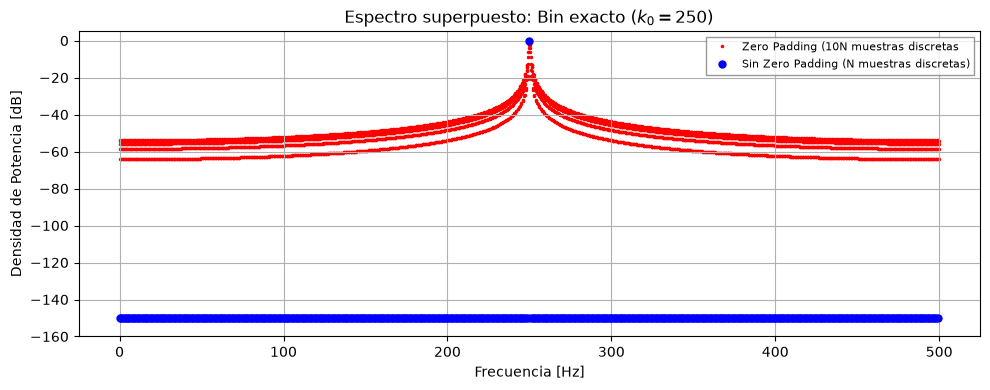

Sin padding: -149.99999999999997
Con padding: -149.99999999999997


In [56]:
#%%

fig, ax = plt.subplots(figsize=(10, 4))


ax.plot(
    frec_pad,
    pdbxx1_pad,
    color='red',
    linestyle='none',
    marker='.',
    markersize=3,
    label='Zero Padding (10N muestras discretas',
    zorder = 1
)


ax.plot(
    frec,
    pdbxx1,
    color='blue',
    linestyle='none',
    marker='o',
    markersize=5,
    label='Sin Zero Padding (N muestras discretas)',
    zorder = 2
)


ax.set_title("Espectro superpuesto: Bin exacto ($k_0 = 250$)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("Densidad de Potencia [dB]")
ax.set_ylim(-160, 5)
ax.grid(True)

ax.legend(
    frameon=True,
    fancybox=False,
    edgecolor='gray',
    fontsize=8
)

plt.tight_layout()
plt.show()
print("Sin padding:", pdbxx1[1])
print("Con padding:", pdbxx1_pad[10])

> **Figura 4.** Espectro de la señal sinoidial sin corrimiento (azul) vs Espectro de la señal sinoidial sin corrimiento con zero padding (rojo).

Hare un zoom al lobulo principal de la *Figura 4* para asi poder distinguir mejor lo que pasa.

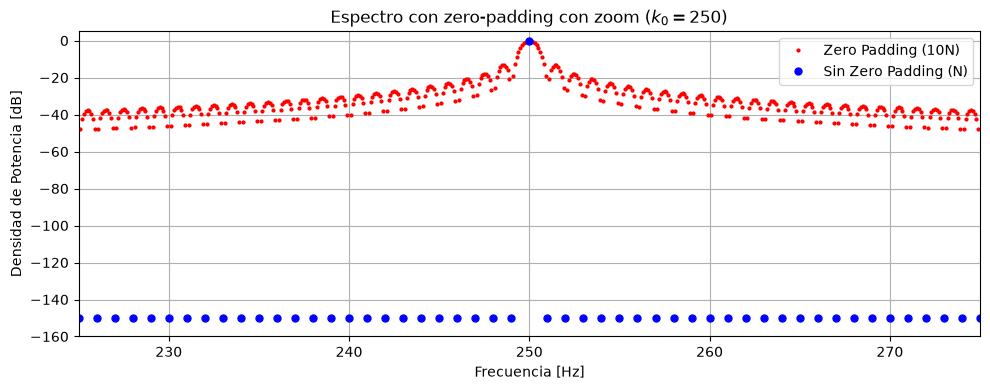

In [57]:
#%%

plt.figure(figsize=(10, 4))



plt.plot(
    frec_pad,
    pdbxx1_pad,
    'o',
    markersize=2,
    linewidth=1,
    color='red',
    label='Zero Padding (10N)'
)


# Sin Zero Padding (N muestras)
plt.plot(
    frec,
    pdbxx1,
    'o',
    markersize=5,
    color='blue',
    label='Sin Zero Padding (N)'
)


plt.xlim(225, 275)
plt.ylim(-160, 5)

plt.title("Espectro con zero-padding con zoom ($k_0 = 250$)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

> **Figura 5.** Espectro con zoom de la señal sinoidial sin corrimiento (azul) vs espectro de la señal sinoidial sin corrimiento con zero padding (rojo).

En la **Figura 5** se puede observar con mayor claridad la estructura de la función **sinc periódica** que aparece en el espectro. Al agregar $9N$ ceros a la señal, se pasa de $N$ a $10N$ muestras para calcular la DFT, por lo que se obtiene una grilla de frecuencias mucho más densa. Esto permite ver con mayor detalle la forma del espectro entre los puntos que se obtenían originalmente.

Para el caso del bin exacto, la muestra ubicada en $250$ Hz coincide con el máximo de la sinc y alcanza los $0$ dB. En cambio, las muestras de la DFT original que quedan a una distancia de $m\Delta f$ respecto de la frecuencia central coinciden con los ceros de la función, por lo que prácticamente no se observa energía en esos puntos y los valores quedan cerca del piso numérico.

De esta forma, se puede ver que el *zero padding* no cambia la resolución espectral de la señal, ya que el ancho del lóbulo principal sigue estando determinado por las $N$ muestras originales. Lo que cambia es la cantidad de puntos con los que se representa el espectro, permitiendo apreciar la forma de los lóbulos secundarios y la estructura que queda oculta cuando se utilizan solamente los puntos de la DFT original.


Ahora vamos con el espectro corrido +0,25

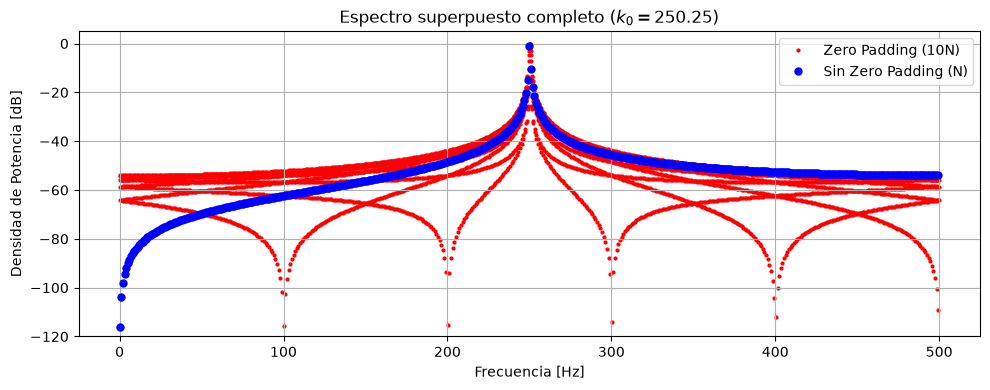

Sin padding: -103.79251313924415
Con padding: -103.79251313924539


In [58]:
#%% 


fxx2_pad = np.fft.fft(xx2_pad) / N
fmxx2_pad = fxx2_pad[:N_pad // 2]

pxx2_pad = 2 * (np.abs(fmxx2_pad)) ** 2

pdbxx2_pad = 10 * np.log10(pxx2_pad + 1e-15)


plt.figure(figsize=(10, 4))


plt.plot(
    frec_pad,
    pdbxx2_pad,
    'o',
    markersize=2,
    linewidth=1,
    color='red',
    label='Zero Padding (10N)',
    zorder = 1
)


plt.plot(
    frec,
    pdbxx2,
    'o',
    markersize=5,
    color='blue',
    label='Sin Zero Padding (N)',
    zorder = 2
)


plt.ylim(-120, 5)

plt.title("Espectro superpuesto completo ($k_0 = 250.25$)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
print("Sin padding:", pdbxx2[1])
print("Con padding:", pdbxx2_pad[10])

> **Figura 6.** Espectro de la señal sinoidial con corrimiento de 0.25 (azul) vs Espectro de la señal sinoidial con corrimiento de 0.25 con zero padding (rojo).

En la **Figura 6** se observa el efecto de una desintonía de un cuarto de bin, correspondiente a $f_0 = 250.25\text{ Hz}$. Al comparar ambas curvas, se puede ver que en las frecuencias que comparten las dos grillas, separadas $1\text{ Hz}$, los valores obtenidos son idénticos. Esto es esperable, ya que el zero padding no modifica los valores de la DFT original, sino que agrega puntos entre ellos.

Al agregar los ceros, aparecen nueve muestras nuevas entre cada par de frecuencias enteras. De esta manera, se puede apreciar con mucho más detalle la forma del espectro y la caída de los lóbulos producida por el desparramo espectral (spectral leakage).

También se puede observar mejor la posición del máximo. Como la frecuencia de la señal es $250.25\text{ Hz}$, la DFT original no tiene un punto exactamente en esa frecuencia y su valor máximo queda en $250\text{ Hz}$. En cambio, con zero padding aparecen puntos mucho más cercanos a $250.25\text{ Hz}$, permitiendo visualizar que el máximo real del lóbulo está prácticamente en $0\text{ dB}$. La diferencia observada en la DFT original corresponde entonces al scalloping loss, causado por la posición de la frecuencia respecto de los bins disponibles.

Ahora hare zoom al lobulo principal.

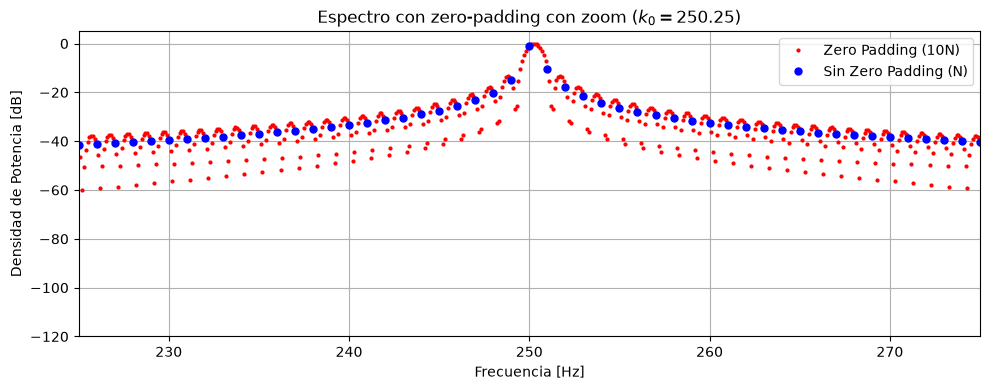

In [59]:
#%% 

plt.figure(figsize=(10, 4))


plt.plot(
    frec_pad,
    pdbxx2_pad,
    'o',
    markersize=2,
    linewidth=1,
    color='red',
    label='Zero Padding (10N)'
)


plt.plot(
    frec,
    pdbxx2,
    'o',
    markersize=5,
    color='blue',
    label='Sin Zero Padding (N)'
)


plt.xlim(225, 275)
plt.ylim(-120, 5)

plt.title("Espectro con zero-padding con zoom ($k_0 = 250.25$)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

> **Figura 7.** Espectro con zoom de la señal sinoidial con corrimiento de 0.25 (azul) vs espectro de la señal sinoidial con corrimiento de 0.25 con zero padding (rojo).

En la **Figura 7** podemos observar con mayor claridad cómo el pico de la señal con padding está en 250.25 Hz, colocándose justo en 0 dB. Esto nos muestra nuevamente que al realizar zero padding podemos apreciar mejor lo que sucede entre bines, pero sin incorporar información que no haya tenido la señal originalmente.
Tambien queda evidenciado el fenómeno de Scalloping Loss en la DFT original (puntos azules), la cual muestreaba únicamente en los bines adyacentes de $250\text{ Hz}$ y $251\text{ Hz}$), perdiendo la observación del pico real por falta de densidad en la grilla espectral.

Ahora vamos con el espectro corrido +0.5

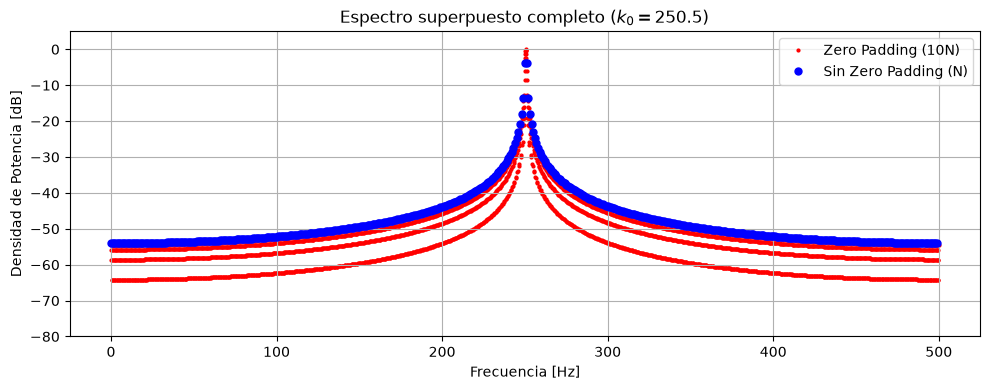

Sin padding: -54.006516740825816
Con padding: -54.00651674082585


In [60]:
#%% 


fxx3_pad = np.fft.fft(xx3_pad) / N
fmxx3_pad = fxx3_pad[:N_pad // 2]

pxx3_pad = 2 * (np.abs(fmxx3_pad)) ** 2

pdbxx3_pad = 10 * np.log10(pxx3_pad + 1e-15)


plt.figure(figsize=(10, 4))


plt.plot(
    frec_pad,
    pdbxx3_pad,
    'o',
    markersize=2,
    linewidth=1,
    color='red',
    label='Zero Padding (10N)',
    zorder = 1
)


plt.plot(
    frec,
    pdbxx3,
    'o',
    markersize=5,
    color='blue',
    label='Sin Zero Padding (N)',
    zorder = 2
)


plt.ylim(-80, 5)

plt.title("Espectro superpuesto completo ($k_0 = 250.5$)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()
print("Sin padding:", pdbxx3[1])
print("Con padding:", pdbxx3_pad[10])

> **Figura 8.** Espectro de la señal sinoidial con corrimiento de 0.5 (azul) vs Espectro de la señal sinoidial con corrimiento de 0.5 con zero padding (rojo).

En la **Figura 8** se observa el caso de mayor desintonía, con la frecuencia de la señal ubicada exactamente a mitad de camino entre dos bins, es decir, $f_0 = 250.5\text{ Hz}$. Al comparar ambos espectros, se puede ver que en las frecuencias que comparten las dos grillas, separadas $1\text{ Hz}$, los valores coinciden punto por punto. Esto se debe a que el zero padding no modifica los valores originales de la DFT, sino que agrega muestras entre ellos.

En este caso el desparramo espectral es más notorio que en los casos anteriores. Como la frecuencia queda justo entre dos bins, la energía se distribuye de forma simétrica alrededor de la frecuencia de la señal. Al agregar zero padding aparecen nueve puntos adicionales entre cada par de bins originales, lo que permite observar con mayor detalle la forma de los lóbulos y la envolvente de la función sinc que genera el desparramo espectral.

Ahora hago zoom al lobulo principal.

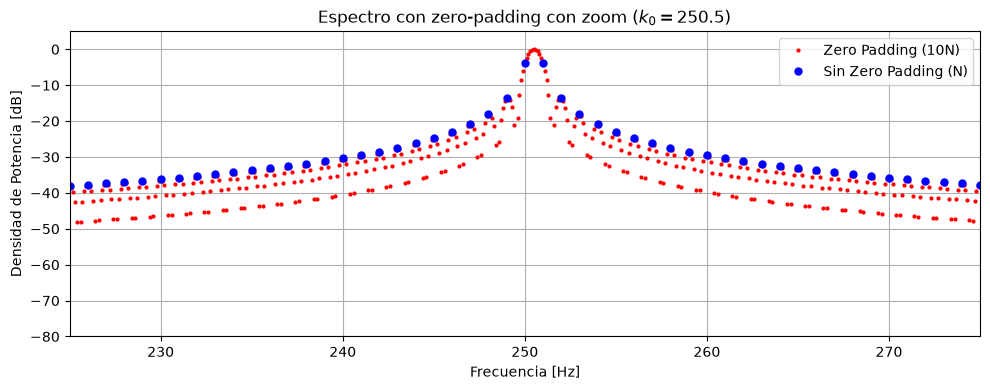

In [61]:
#%% Figura 9: Espectro con zero-padding con zoom (k0 = 250.5)

plt.figure(figsize=(10, 4))


# Zero Padding (10N muestras)
plt.plot(
    frec_pad,
    pdbxx3_pad,
    'o',
    markersize=2,
    linewidth=1,
    color='red',
    label='Zero Padding (10N)'
)


# Sin Zero Padding (N muestras)
plt.plot(
    frec,
    pdbxx3,
    'o',
    markersize=5,
    color='blue',
    label='Sin Zero Padding (N)'
)


plt.xlim(225, 275)
plt.ylim(-80, 5)

plt.title("Espectro con zero-padding con zoom ($k_0 = 250.5$)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Densidad de Potencia [dB]")

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

> **Figura 9.** Espectro con zoom de la señal sinoidial con corrimiento de 0.5 (azul) vs espectro de la señal sinoidial con corrimiento de 0.5 con zero padding (rojo).

En la **Figura 9** se puede apreciar con mayor detalle el efecto del **scalloping loss** para el caso de una desintonía de medio bin. Como la señal tiene una frecuencia de $250.5\text{ Hz}$, el zero padding agrega suficientes puntos como para que uno de ellos coincida exactamente con esa frecuencia. En ese punto se alcanza el máximo del lóbulo principal.

En cambio, la DFT original solo evalúa el espectro en frecuencias enteras, por lo que no tiene ningún punto en $250.5\text{ Hz}$. Los puntos más cercanos son los de $250\text{ Hz}$ y $251\text{ Hz}$, y ambos presentan un valor que difiere con 0dB. Esta diferencia respecto del máximo corresponde al **scalloping loss** máximo, que aparece cuando la frecuencia de la señal queda exactamente a mitad de camino entre dos bins.

El **zero padding** permite visualizar ese máximo con mayor precisión, pero no agrega información nueva a la señal; simplemente permite evaluar el mismo espectro en una grilla de frecuencias más densa.

## Conclusión

Durante este trabajo experimental se analizaron distintos efectos que aparecen al calcular la Transformada Discreta de Fourier (DFT) de señales de duración finita, y se estudió el efecto del Zero Padding sobre la representación del espectro.

* **Desparramo Espectral (Spectral Leakage):** Se observó que cuando la frecuencia de una señal senoidal no coincide exactamente con un bin de la DFT ($k_0 \notin \mathbb{Z}$), la energía de la señal no queda concentrada en una única frecuencia, sino que se distribuye alrededor de ella. Esto se debe a que la señal está limitada a un número finito de muestras y, en frecuencia, esto se relaciona con la forma de la función sinc. A medida que la frecuencia se aleja de un bin entero, el desparramo de energía entre los distintos bins se hace más evidente.

* **Scalloping Loss:** Debido a que la DFT evalúa el espectro únicamente en frecuencias separadas por $\Delta f = f_S/N$, puede ocurrir que la frecuencia de la señal quede ubicada entre dos bins. En ese caso, el máximo real de la señal no es capturado directamente por la DFT. Este efecto alcanza su valor máximo cuando la frecuencia queda exactamente a mitad de camino entre dos bins, como ocurre para $k_0 = 250.5$.


* **Efecto del Zero Padding:** Al agregar ceros a la señal hasta obtener $N_{\text{pad}} = 10N$ muestras, la separación entre los puntos de la grilla espectral disminuye diez veces, pasando a ser $\Delta f_{\text{pad}} = f_S/(10N)$. Esto permite representar el mismo espectro utilizando muchos más puntos y observar con mayor detalle lo que ocurre entre los bins originales. De esta manera, se puede visualizar mejor la forma del lóbulo principal y lo producido por el desparramo espectral. También permite encontrar puntos más cercanos al máximo real de la señal, haciendo que el scalloping loss sea menos evidente en la representación.

En conclusión, el Zero Padding permite obtener una representación mucho más detallada del espectro y facilita el análisis de los fenómenos observados. Sin embargo, no agrega información nueva a la señal ni mejora su resolución física: el ancho del lóbulo principal continúa estando determinado por las $N$ muestras originales y por la duración del sampling. Por lo tanto, el Zero Padding permite ver mejor el espectro, pero no cambia la información que ya estaba contenida en la señal original.
